# Dynamic Similarity for Compositional Image Retrieval

This is the **single final notebook** for the project. It loads the final trained system from `final_best_system/`, shows the official metrics and qualitative outputs, and contains the training/evaluation commands behind explicit boolean switches.

The final model keeps CLIP frozen and learns only lightweight source-conditioned composition and reranking modules. The winning inference formula is:

```text
q_model = learned_gate(source, query)
q_sum   = generic CLIP arithmetic(source, query)
q_final = normalize(q_model + 1.25 * (q_sum - source))
```

The notebook is designed to be run quickly by default. Heavy operations such as training and full official JSON evaluation are present but disabled unless the boolean flags are changed.

## Methodological Roadmap

This notebook is organized as a compact report plus runnable code. The project follows the assignment idea of building on CLIP compositionality and CLAY-style conditional similarity, but the implementation is our own lightweight pipeline rather than a third-party repository.

**Baseline and motivation.** We first implemented the assignment-style CLIP arithmetic baseline, where a source image embedding is shifted by signed text directions. We then tested several zero-shot variants: direct sums, sequential sums, and contrastive directions built from positive/negative prompt pairs. The strongest zero-shot baseline was the contrastive sequential variant, which motivated treating a multi-attribute query as an ordered composition of semantic directions rather than one long prompt.

**Hybrid compositional core.** The learned model keeps OpenAI CLIP ViT-B/32 frozen. A small sequential gate receives the source image embedding and the signed query directions, then learns how strongly each edit should move the source in CLIP space. The final compositional vector also includes a CLIP-arithmetic correction term:

```text
q_model  = learned sequential gate(source, signed query directions)
q_sum    = contrastive CLIP arithmetic(source, signed query directions)
q_final  = normalize(q_model + beta * (q_sum - source)), beta = 1.25
```

This is the part we consider the main hybrid compositionality contribution: a learned source-conditioned composer plus explicit CLIP semantic arithmetic.

**Training and experimental choices.** Early same-identity training made the model good at retrieving the paired target identity, but it was weak on official JSON queries such as `Male`, `Young`, and `Chubby`, where the official target is not necessarily the same person. We therefore moved to mixed training: same-identity pairs for preservation, official-like synthetic positives for the assignment metric, and weak/global oversampling. We also ran hyperparameter searches over learning rate, source preservation, residual scale, beta, and Hamming-weighted target scores.

**Why a reranker was added.** Oracle top-pool diagnostics showed that the hybrid vector often reaches the right semantic neighbourhood: many official-valid targets appear inside a broad top-500 pool, even when the first top-10 ranking is imperfect. This led to a second-stage calibrated CelebA attribute probe. The final system promotes candidates predicted to satisfy the query and preserve non-query attributes, but fills missing slots with the original CLIP ranking to avoid over-pruning.

**Final reported system.** We report both the hybrid compositional core and the complete retrieval system built on top of it. The complete system improves substantially over the vanilla assignment baseline on Recall@1/5/10 and Precision@1/5/10, while the qualitative examples help explain remaining precision limitations.


## Colab Execution Notes

The code is self-contained, but the notebook expects the submitted project artifacts to be present next to it: `final_best_system/`, `celeba_evaluation.json`, CelebA annotations/images, and the precomputed CLIP image embeddings under `cluster/data/celeba/embeddings/openai_clip_vit_b32/`. In Colab, clone or upload the repository/artifact folder before running the cells. Heavy training and full JSON recomputation are disabled by default through boolean flags so the notebook can be inspected quickly.

All qualitative figures used in the report are embedded directly in this notebook, so they remain visible even when opened in Google Colab.


In [12]:
# Runtime switches. Default values are safe for a quick notebook run.
RUN_INSTALL_DEPS = True
RUN_TRAINING = False
RUN_FULL_JSON_EVALUATION = False
RUN_QUALITATIVE_EXAMPLES = True
RUN_ORACLE_DIAGNOSTIC_SMOKE = False
RUN_FILTERING_MATRIX_RECOMPUTE = False

DEVICE_REQUEST = "auto"
FINAL_BETA = 1.25

# Example used for the quick inference cell.
EXAMPLE_QUERY_ID = 5
EXAMPLE_SOURCE_INDEX = 3
EXAMPLE_TOP_K = 10

In [13]:
if RUN_INSTALL_DEPS:
    import subprocess
    import sys
    subprocess.run([
        sys.executable, "-m", "pip", "install",
        "torch", "torchvision", "pandas", "matplotlib", "pillow", "tqdm"
    ], check=True)
else:
    print("Dependency installation skipped. Set RUN_INSTALL_DEPS=True only if needed.")


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## Project Paths and Imports

The notebook searches upward from the current working directory until it finds `final_best_system/` and `cluster/`. This makes it runnable both from the repository root and from the `notebooks/` directory.

In [14]:
from __future__ import annotations

import json
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn.functional as F
from IPython.display import Image as IPyImage, display


def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "final_best_system").is_dir() and (candidate / "cluster").is_dir():
            return candidate
    raise RuntimeError("Could not find a project root containing final_best_system/ and cluster/.")


PROJECT_ROOT = find_project_root()
CLUSTER_ROOT = PROJECT_ROOT / "cluster"
FINAL_DIR = PROJECT_ROOT / "final_best_system"
FINAL_CODE = FINAL_DIR / "code"
FINAL_SCRIPTS = FINAL_CODE / "scripts"
FINAL_ORCH = FINAL_CODE / "orchestrator"

# The final-system helper modules use DL_PROJECT_ROOT to locate CelebA annotations and embeddings.
os.environ["DL_PROJECT_ROOT"] = str(CLUSTER_ROOT)
sys.path.insert(0, str(FINAL_SCRIPTS))
sys.path.insert(0, str(FINAL_ORCH))

from learned_gate_core import condition_embeddings, load_model_checkpoint, load_prompt_embedding_cache
from project_core import choose_device, load_torch, parse_query, read_attribute_table

print("PROJECT_ROOT:", PROJECT_ROOT)
print("FINAL_DIR:", FINAL_DIR)

PROJECT_ROOT: /Users/kuba/deep_learning
FINAL_DIR: /Users/kuba/deep_learning/final_best_system


## Assignment Metric Definition

The assignment defines `Recall@K` as a **hit-rate**:

```text
Recall@K = 1 if at least one official-valid target appears in top-K, otherwise 0
Precision@K = number of official-valid targets in top-K / K
```

Therefore, a method can have good Recall@10 while still having low Precision@10. This means it often finds at least one valid target, but does not fill the entire top-10 with valid targets.

## Load the Final System

This cell loads:

- the final trained checkpoint from `final_best_system/weights/`;
- the signed prompt embedding cache used by the gate;
- the CLIP text directions used by the arithmetic correction;
- the frozen test image embedding gallery.

In [15]:
DEVICE = choose_device(DEVICE_REQUEST)
print("Device:", DEVICE)

FINAL_CHECKPOINT_PATH = FINAL_DIR / "weights" / "best_val_official_like_at10.pt"
PROMPT_CACHE_PATH = FINAL_DIR / "embeddings" / "signed_attribute_prompt_embeddings_v2_photo_templates.pt"
TEXT_DIRECTIONS_PATH = FINAL_DIR / "embeddings" / "attribute_text_embeddings.pt"
TEST_EMBEDDINGS_PATH = CLUSTER_ROOT / "data" / "celeba" / "embeddings" / "openai_clip_vit_b32" / "test_image_embeddings.pt"
EVAL_JSON_PATH = PROJECT_ROOT / "celeba_evaluation.json"
if not EVAL_JSON_PATH.exists():
    EVAL_JSON_PATH = CLUSTER_ROOT / "data" / "celeba_evaluation.json"

required = [FINAL_CHECKPOINT_PATH, PROMPT_CACHE_PATH, TEXT_DIRECTIONS_PATH, TEST_EMBEDDINGS_PATH, EVAL_JSON_PATH]
for p in required:
    assert p.exists(), f"Missing required file: {p}"

final_model, final_checkpoint = load_model_checkpoint(FINAL_CHECKPOINT_PATH, DEVICE)
final_model.eval()
final_config = final_checkpoint["config"]

prompt_cache = load_prompt_embedding_cache(PROMPT_CACHE_PATH)
text_bank = load_torch(TEXT_DIRECTIONS_PATH)
text_directions = F.normalize(text_bank["directions"].float().to(DEVICE), dim=-1)

gallery_cache = load_torch(TEST_EMBEDDINGS_PATH)
gallery = F.normalize(gallery_cache["embeddings"].float().to(DEVICE), dim=-1)
gallery_filenames = list(gallery_cache["filenames"])

attributes, _, _ = read_attribute_table()
attribute_to_index = {name: i for i, name in enumerate(attributes)}
evaluation_json = json.loads(EVAL_JSON_PATH.read_text())

print("Checkpoint:", FINAL_CHECKPOINT_PATH)
print("Prompt cache:", PROMPT_CACHE_PATH.name)
print("Gallery:", gallery.shape)
print("Official JSON query entries:", len(evaluation_json))

Device: mps
Checkpoint: /Users/kuba/deep_learning/final_best_system/weights/best_val_official_like_at10.pt
Prompt cache: signed_attribute_prompt_embeddings_v2_photo_templates.pt
Gallery: torch.Size([19962, 512])
Official JSON query entries: 14


## Final Inference Function

For each source image and textual modification query, the system computes:

```text
q_model = learned_gate(source, query)
q_sum   = normalize(source + sum signed CLIP text directions)
q_final = normalize(q_model + beta * (q_sum - source))
```

Retrieval then ranks every gallery image by cosine similarity with `q_final`.

In [16]:
def condition_tensors_for_query(conditions, batch_size, device):
    max_len = max(1, len(conditions))
    attrs = torch.full((batch_size, max_len), -1, dtype=torch.long, device=device)
    signs = torch.zeros((batch_size, max_len), dtype=torch.int8, device=device)
    for pos, (sign, attr) in enumerate(conditions):
        attrs[:, pos] = attribute_to_index[attr]
        signs[:, pos] = int(sign)
    return attrs, signs


def learned_gate_query(source_embeddings, conditions):
    source_embeddings = F.normalize(source_embeddings.float().to(DEVICE), dim=-1)
    attrs, signs = condition_tensors_for_query(conditions, len(source_embeddings), DEVICE)
    cond, mask = condition_embeddings(
        prompt_cache,
        attrs,
        signs,
        DEVICE,
        str(final_config.get("condition_mode", "signed_direction")),
    )
    with torch.inference_mode():
        q_model, alpha, _ = final_model(source_embeddings, cond, mask)
    return F.normalize(q_model, dim=-1), alpha


def generic_sum_query(source_embeddings, conditions):
    source_embeddings = F.normalize(source_embeddings.float().to(DEVICE), dim=-1)
    edit = torch.zeros_like(source_embeddings)
    for sign, attr in conditions:
        edit = edit + int(sign) * text_directions[attribute_to_index[attr]].unsqueeze(0)
    edit = F.normalize(edit, dim=-1)
    return F.normalize(source_embeddings + edit, dim=-1)


def final_query(source_embeddings, query_text, beta=FINAL_BETA):
    conditions = parse_query(query_text)
    q_model, alpha = learned_gate_query(source_embeddings, conditions)
    q_sum = generic_sum_query(source_embeddings, conditions)
    q_final = F.normalize(q_model + float(beta) * (q_sum - F.normalize(source_embeddings.float().to(DEVICE), dim=-1)), dim=-1)
    return q_final, {"conditions": conditions, "alpha": alpha.detach().cpu(), "q_model": q_model.detach().cpu(), "q_sum": q_sum.detach().cpu()}


def retrieve_topk_for_source(query_id, source_index, top_k=10, beta=FINAL_BETA):
    query_text = evaluation_json[query_id]["query"]
    source = gallery[[source_index]]
    q_final, details = final_query(source, query_text, beta=beta)
    scores = q_final @ gallery.T
    scores[0, source_index] = -torch.inf
    top = scores.topk(top_k, dim=1).indices[0].detach().cpu().tolist()
    valid_targets = set(map(int, evaluation_json[query_id]["ground_truth"].get(str(source_index), [])))
    rows = []
    for rank, idx in enumerate(top, start=1):
        rows.append({
            "rank": rank,
            "test_index": idx,
            "filename": gallery_filenames[idx],
            "official_json_valid": idx in valid_targets,
        })
    return pd.DataFrame(rows), details

## Quick Inference Smoke Test

This cell recomputes the final vector from the final checkpoint and retrieves top-10 images for one official JSON source/query case. It does **not** use the precomputed `retrievals.jsonl`.

In [17]:
query_text = evaluation_json[EXAMPLE_QUERY_ID]["query"]
print(f"Example query_id={EXAMPLE_QUERY_ID}: {query_text}")
print(f"Source index: {EXAMPLE_SOURCE_INDEX}, filename: {gallery_filenames[EXAMPLE_SOURCE_INDEX]}")

example_topk, example_details = retrieve_topk_for_source(EXAMPLE_QUERY_ID, EXAMPLE_SOURCE_INDEX, EXAMPLE_TOP_K)
display(example_topk)
print("Gate alpha values:", example_details["alpha"].numpy().round(3).tolist())

Example query_id=5: +Blond_Hair
Source index: 3, filename: 182641.jpg


,rank,test_index,filename,official_json_valid
0,1,11084,193722.jpg,False
1,2,18761,201399.jpg,False
2,3,10657,193295.jpg,True
3,4,17565,200203.jpg,False
4,5,13382,196020.jpg,False
5,6,15773,198411.jpg,False
6,7,6234,188872.jpg,False
7,8,13310,195948.jpg,False
8,9,12903,195541.jpg,True
9,10,7849,190487.jpg,False


Gate alpha values: [[0.15800000727176666]]


## Official Results Saved in the Repository

The full official evaluation over all 33,052 source-query pairs has already been run on the cluster and copied into `final_best_system/results/`. The table below compares:

1. assignment baseline: direct CLIP arithmetic;
2. strongest zero-shot CLIP baseline: contrastive sequential arithmetic;
3. final learned system: learned gate + generic arithmetic correction.

Macro metrics: each query counts equally.


,system,method,macro_Recall@1,macro_Recall@5,macro_Recall@10,macro_Precision@1,macro_Precision@5,macro_Precision@10
0,Assignment baseline,direct_sum,0.023967,0.071827,0.108424,0.023967,0.017568,0.014712
1,Strong CLIP baseline,contrastive_sequential,0.040636,0.123810,0.187076,0.040636,0.031001,0.026976
2,Final best system,model_plus_generic_delta_beta_1p50,0.086418,0.263710,0.391472,0.086418,0.072713,0.062885


Micro metrics: every source-query case counts equally.


,system,method,micro_Recall@1,micro_Recall@5,micro_Recall@10,micro_Precision@1,micro_Precision@5,micro_Precision@10
0,Assignment baseline,direct_sum,0.025717,0.081478,0.124773,0.025717,0.020265,0.017681
1,Strong CLIP baseline,contrastive_sequential,0.034461,0.109494,0.166525,0.034461,0.027793,0.024183
2,Final best system,model_plus_generic_delta_beta_1p50,0.066895,0.209579,0.313657,0.066895,0.055283,0.049274


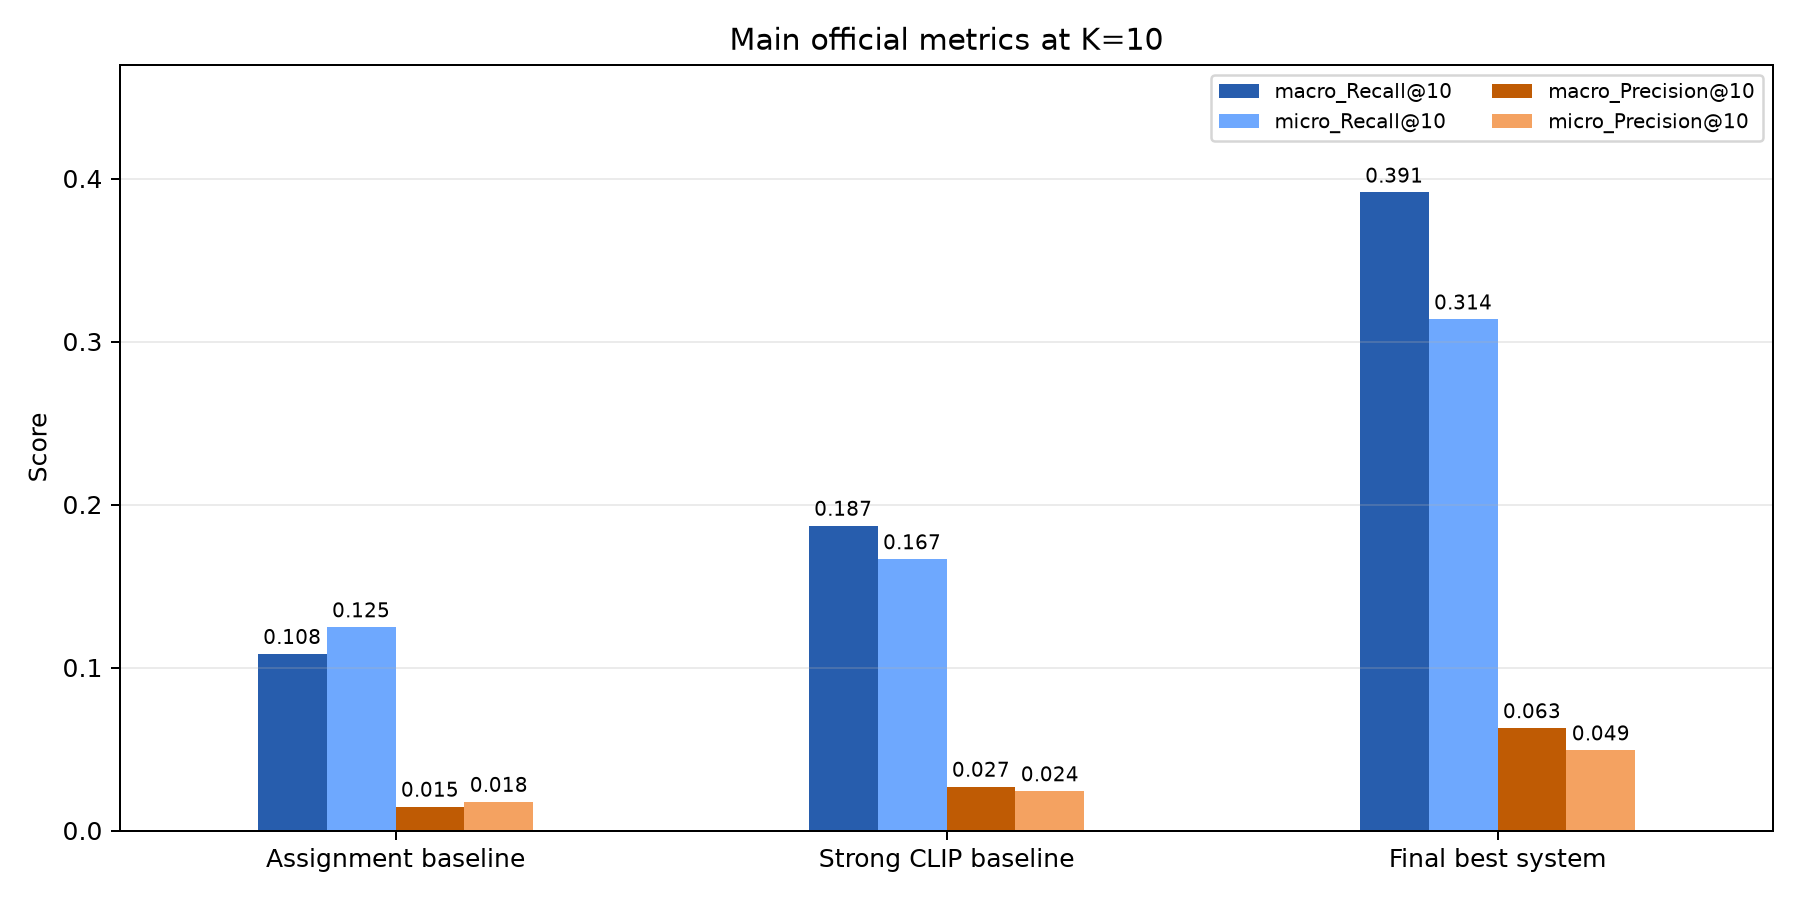

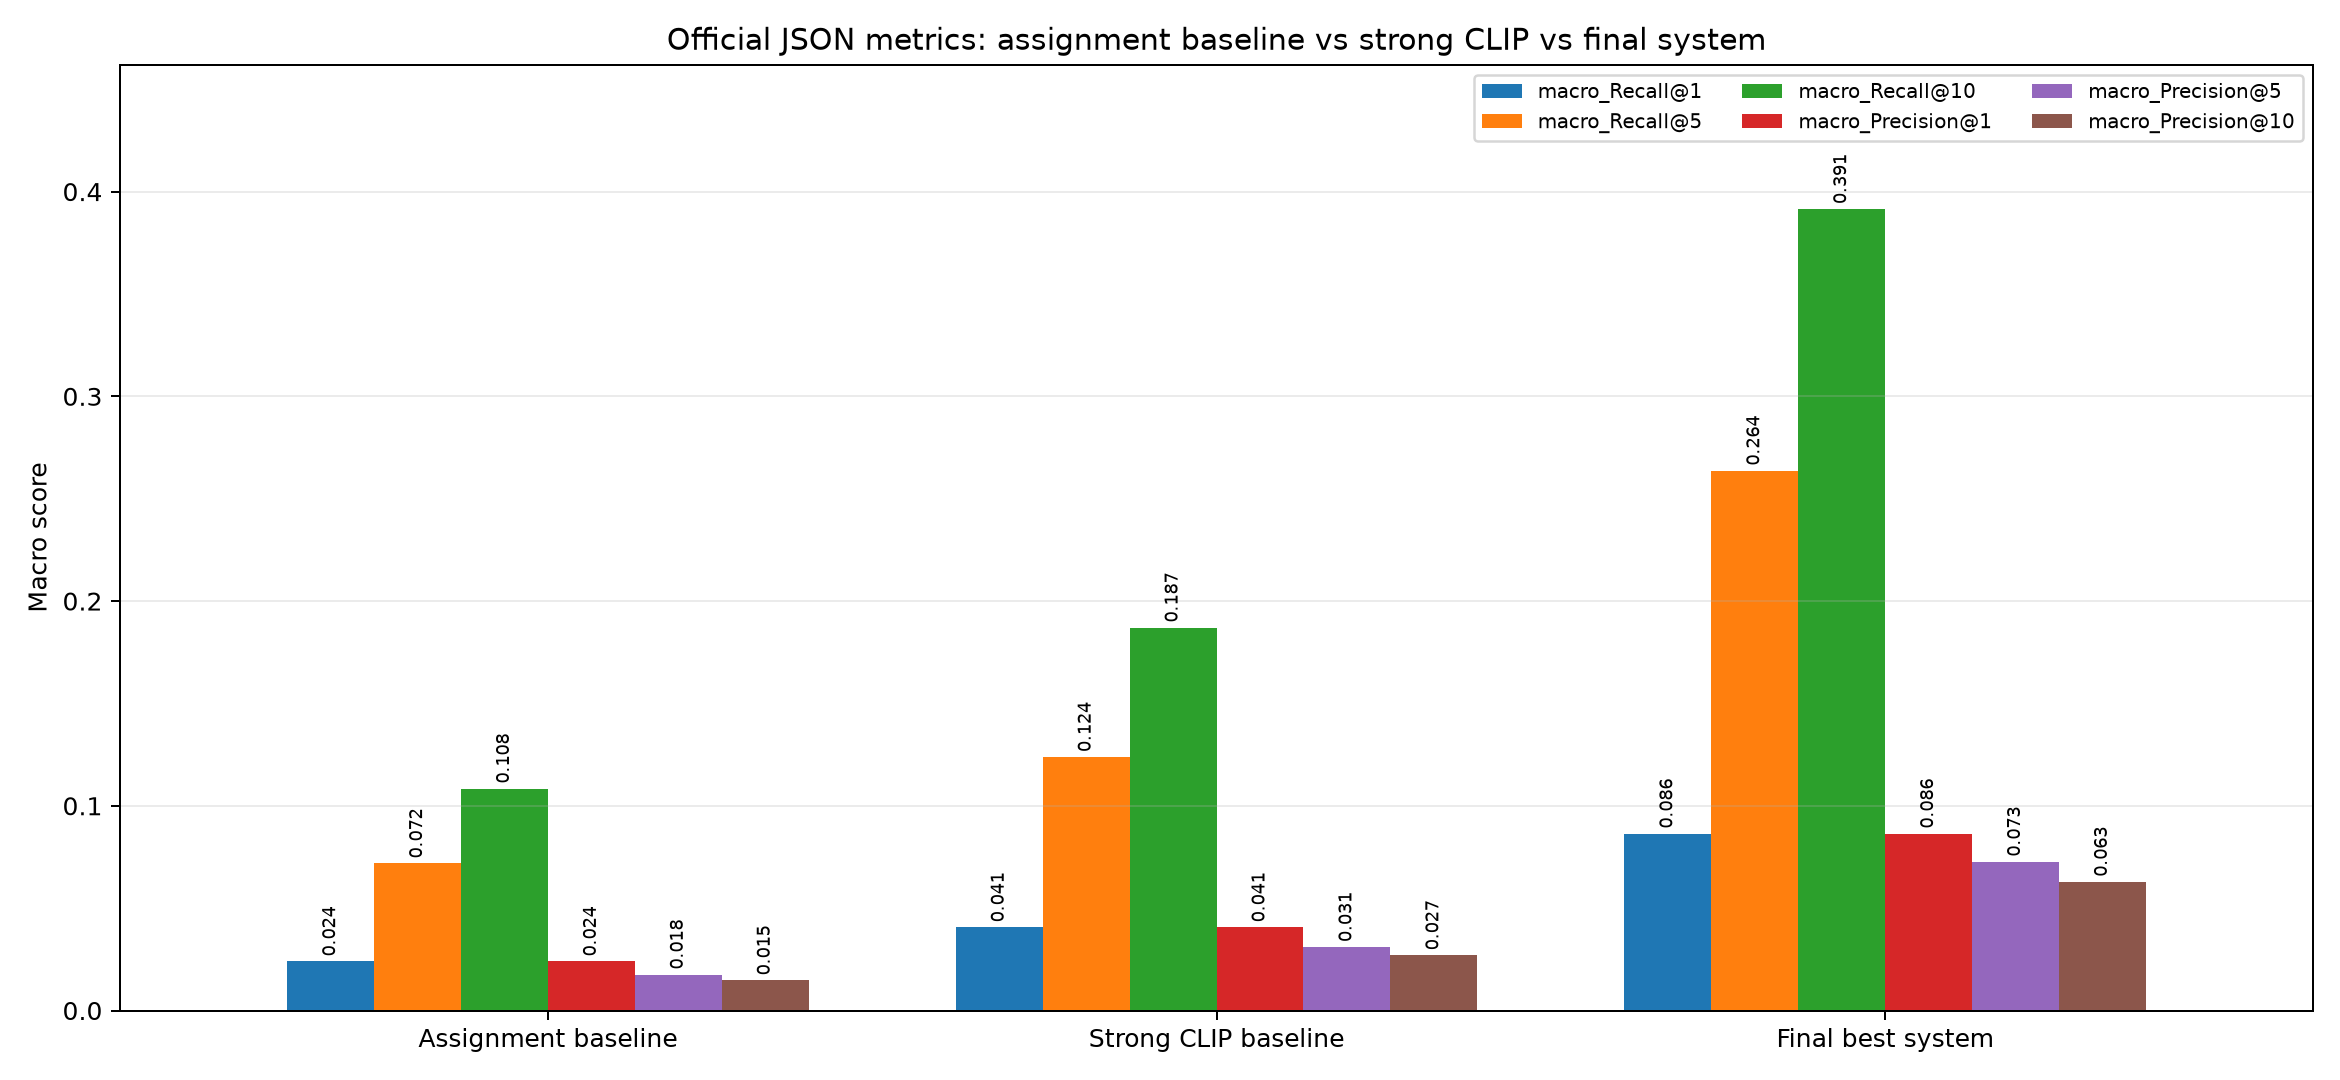

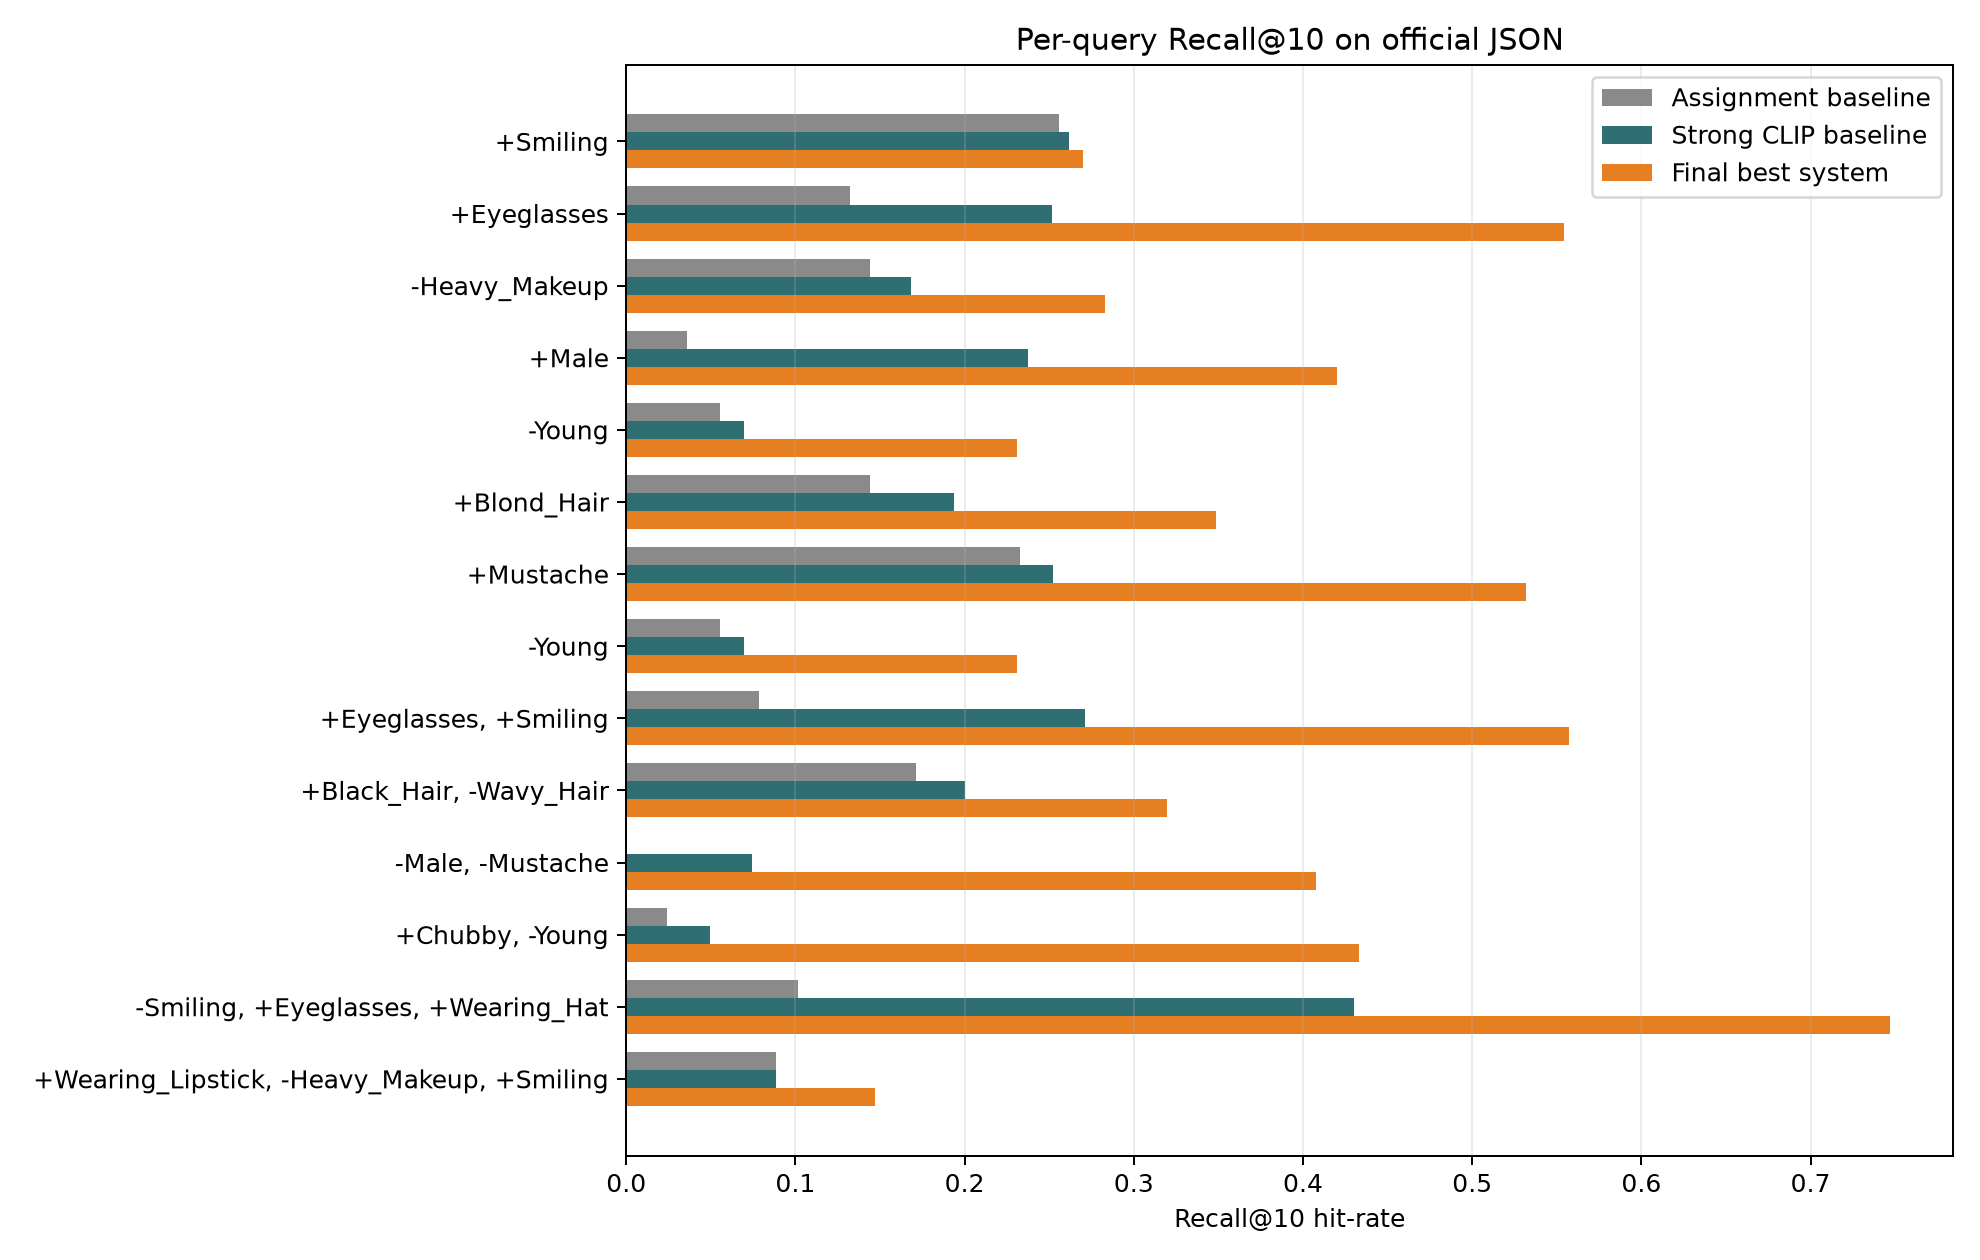

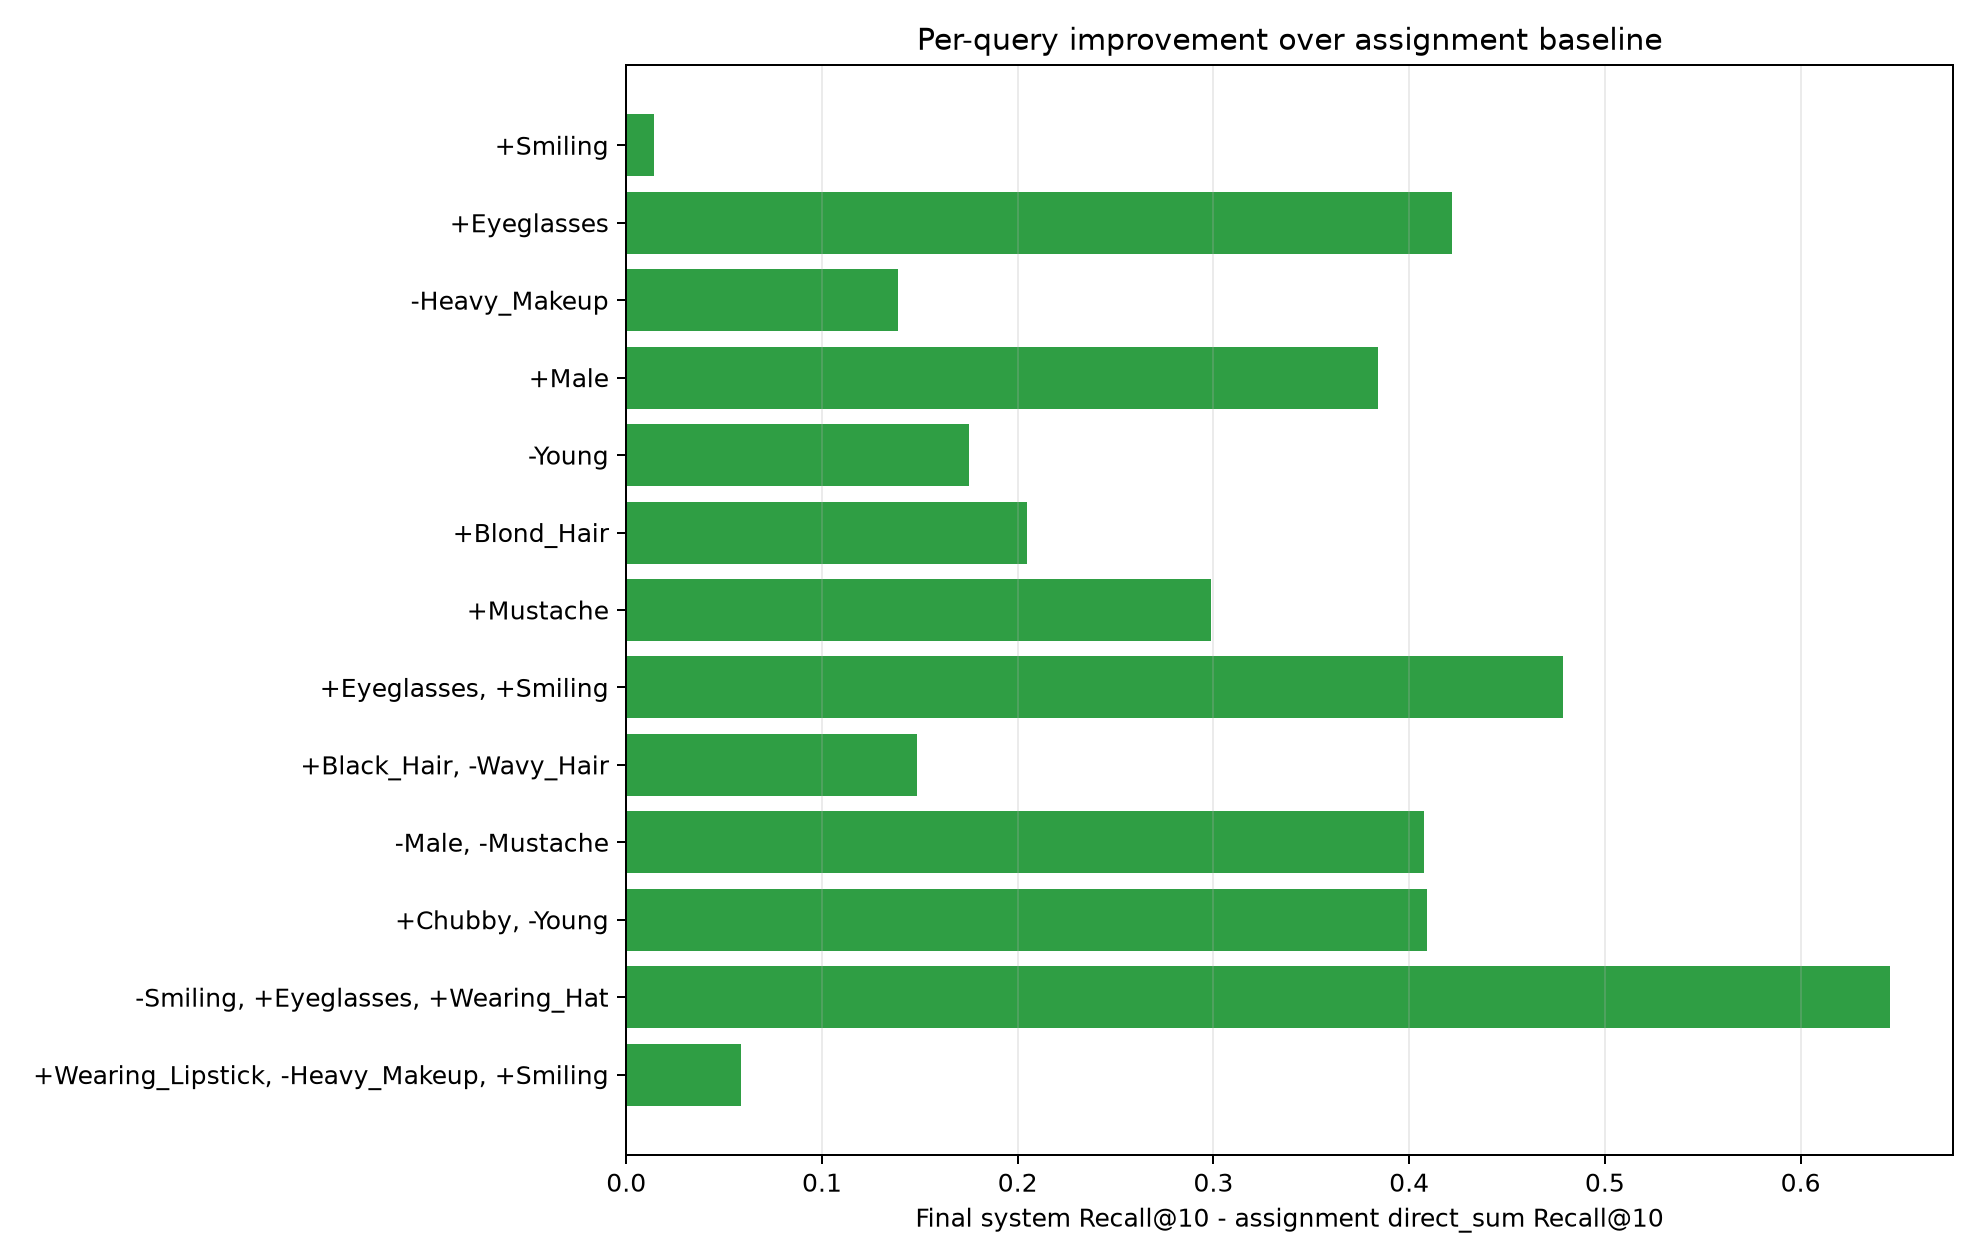

In [18]:
macro_metrics = pd.read_csv(FINAL_DIR / "results" / "clean_report" / "overall_metrics_macro.csv")
micro_metrics = pd.read_csv(FINAL_DIR / "results" / "clean_report" / "overall_metrics_micro.csv")
all_metrics = pd.read_csv(FINAL_DIR / "results" / "clean_report" / "overall_metrics_three_systems.csv")
per_query = pd.read_csv(FINAL_DIR / "results" / "clean_report" / "per_query_recall10_three_systems.csv")

print("Macro metrics: each query counts equally.")
display(macro_metrics)

print("Micro metrics: every source-query case counts equally.")
display(micro_metrics)

for image_name in [
    "overall_metrics_k10_focus.png",
    "overall_metrics_three_systems.png",
    "per_query_recall10_three_systems.png",
    "per_query_recall10_improvement.png",
]:
    image_path = FINAL_DIR / "results" / "clean_report" / image_name
    if image_path.exists():
        display(IPyImage(filename=str(image_path)))

## Qualitative Examples

The qualitative viewer shows:

- blue: source/input image;
- light green: official-valid JSON target;
- yellow: satisfies the requested query attributes, but is not JSON-valid;
- red: fails at least one requested query attribute.

This helps diagnose whether a retrieved image fails because it violates the requested edit or because it does not satisfy the stricter official Hamming/source-preservation rule.

Saved: /Users/kuba/deep_learning/final_best_system/results/qualitative_examples/query_05_source_3_top10.png
Saved: /Users/kuba/deep_learning/final_best_system/results/qualitative_examples/query_05_source_3_top10.json
Query 5 (+Blond_Hair) source=3: 2/10 valid in top-10


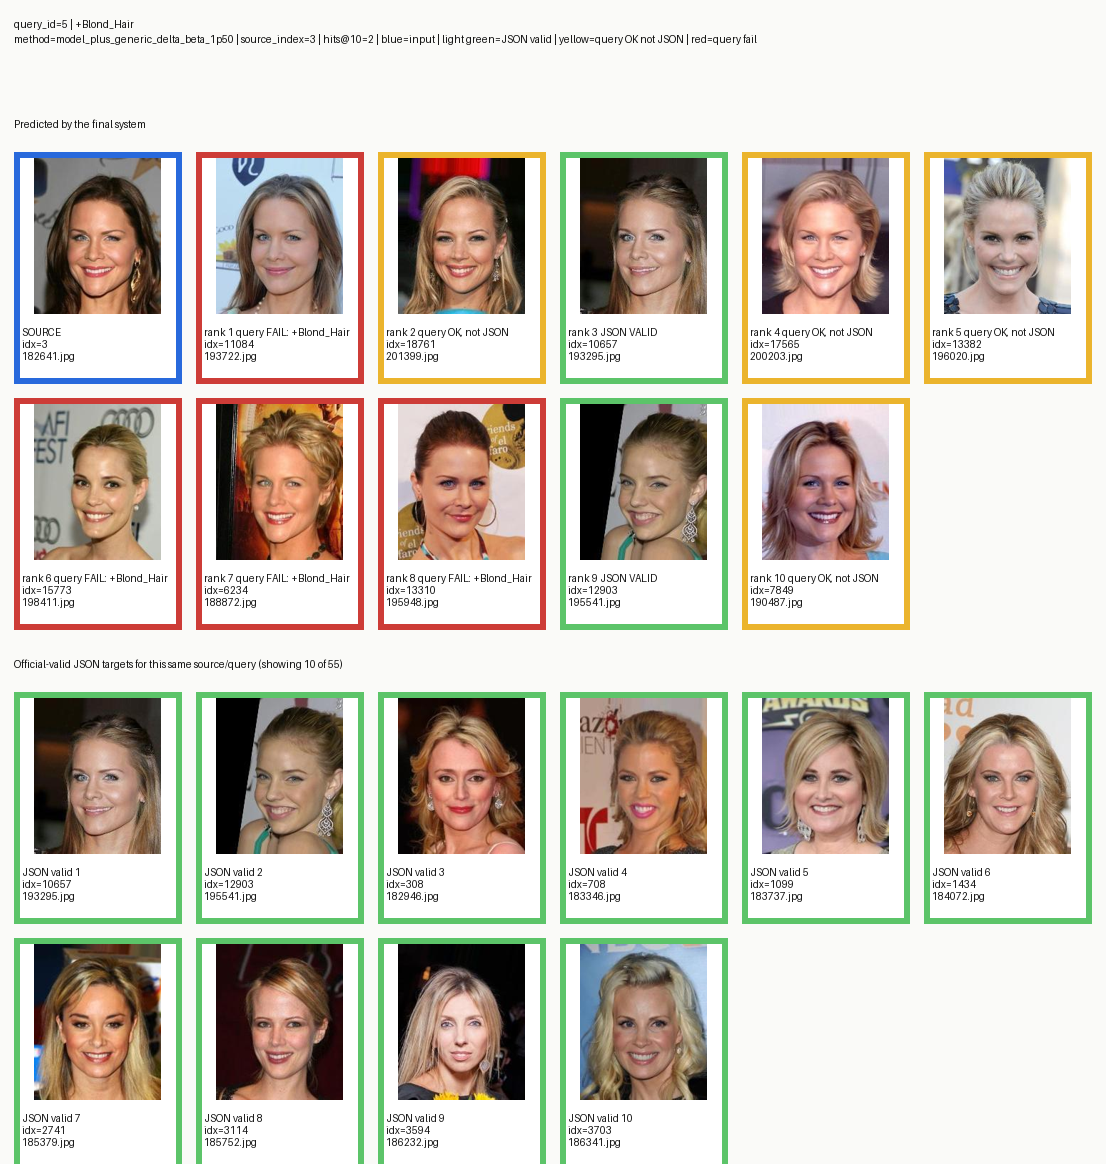

Saved: /Users/kuba/deep_learning/final_best_system/results/qualitative_examples/query_12_source_37_top10.png
Saved: /Users/kuba/deep_learning/final_best_system/results/qualitative_examples/query_12_source_37_top10.json
Query 12 (-Smiling, +Eyeglasses, +Wearing_Hat) source=37: 2/10 valid in top-10


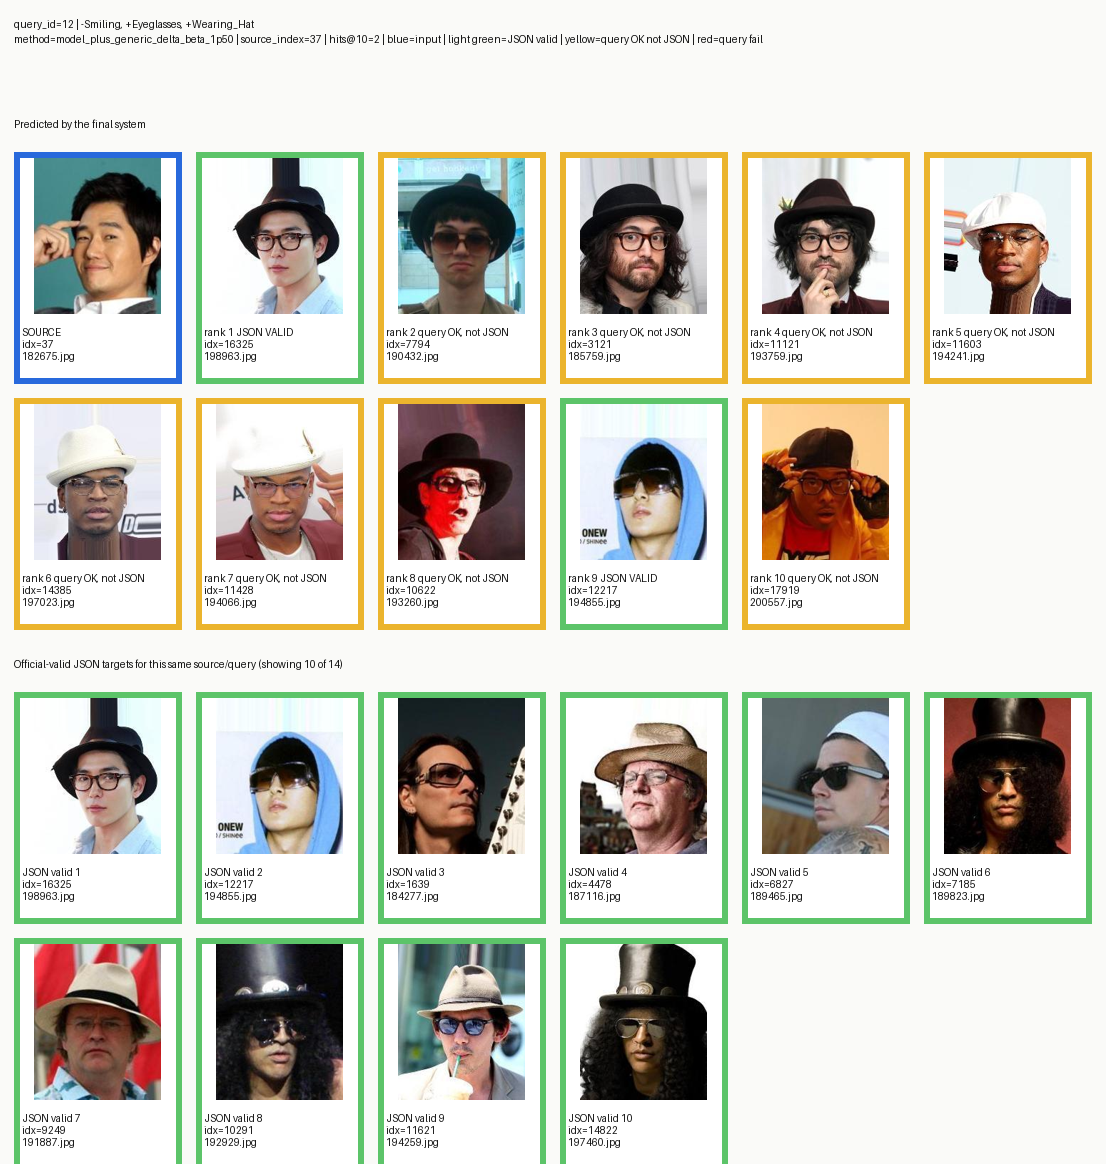

Saved: /Users/kuba/deep_learning/final_best_system/results/qualitative_examples/query_13_source_3977_top10.png
Saved: /Users/kuba/deep_learning/final_best_system/results/qualitative_examples/query_13_source_3977_top10.json
Query 13 (+Wearing_Lipstick, -Heavy_Makeup, +Smiling) source=3977: 1/10 valid in top-10


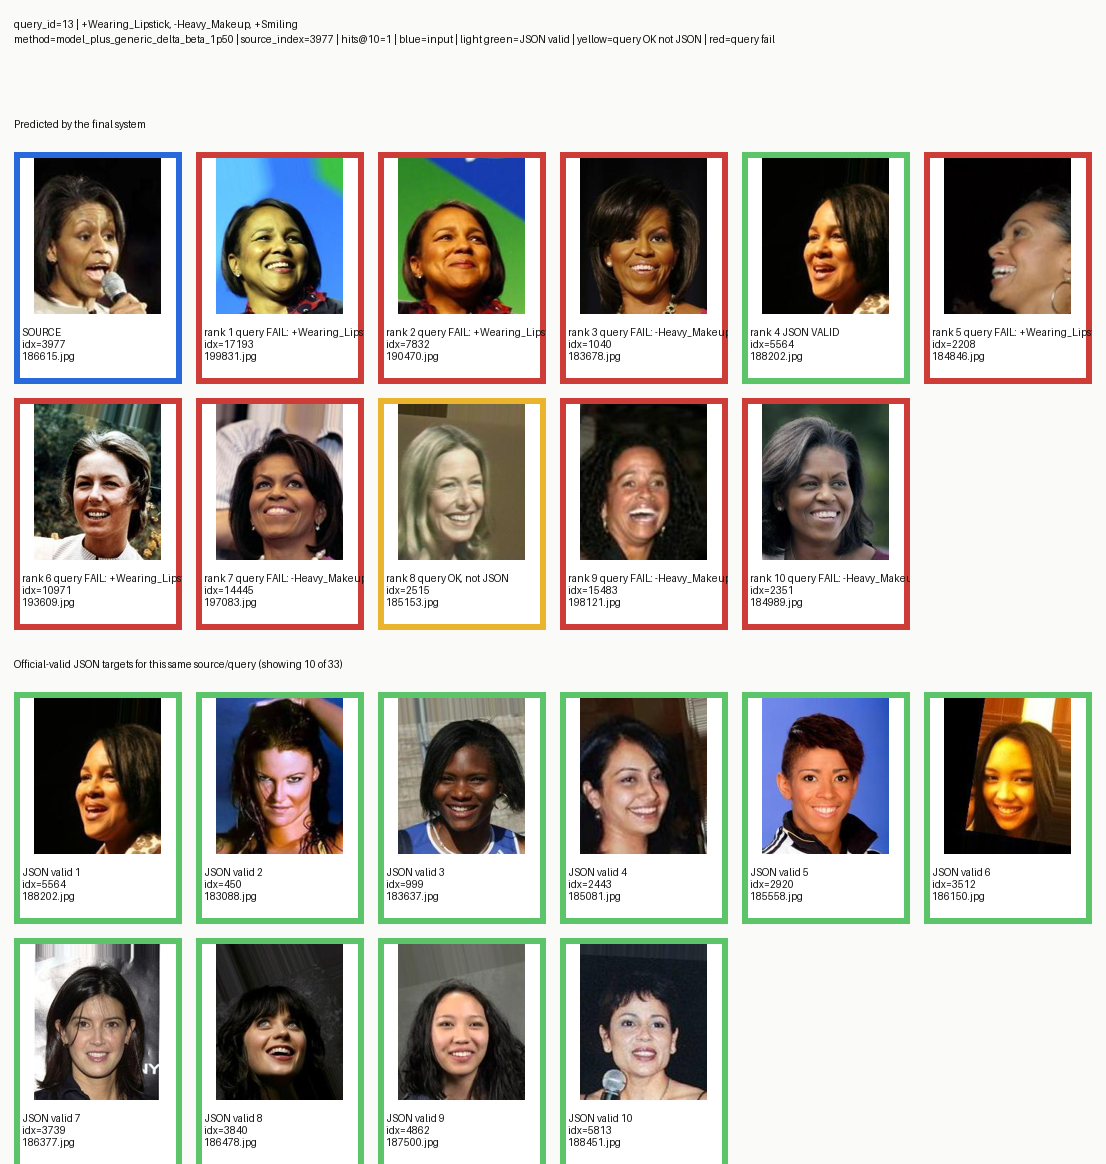

In [19]:
if RUN_QUALITATIVE_EXAMPLES:
    qualitative_examples = [
        (5, 3),      # +Blond_Hair
        (12, 37),    # -Smiling, +Eyeglasses, +Wearing_Hat
        (13, 3977),  # +Wearing_Lipstick, -Heavy_Makeup, +Smiling
    ]
    for query_id, source_index in qualitative_examples:
        subprocess.run(
            [
                sys.executable,
                str(FINAL_DIR / "code" / "show_json_retrieval_example.py"),
                "--query-id", str(query_id),
                "--source-index", str(source_index),
                "--top-k", "10",
                "--no-open",
            ],
            check=True,
            cwd=PROJECT_ROOT,
        )
        path = FINAL_DIR / "results" / "qualitative_examples" / f"query_{query_id:02d}_source_{source_index}_top10.png"
        display(IPyImage(filename=str(path)))
else:
    print("Qualitative examples skipped.")

## Training Code, Disabled by Default

The final model was trained on the cluster. The training pipeline is included here for reproducibility but is disabled by default because it can take hours.

The v6 training strategy mixes:

```text
60% official-like multi-positive pairs from train split, Hamming <= 2
30% same-identity source-preservation pairs
10% weak/global attribute oversampling
```

The official test JSON is **not** used to construct training pairs.

In [20]:
# Toggle RUN_TRAINING=True at the top of the notebook to run this.
# On a laptop, keep profile="short" for a smoke test. On the cluster, use profile="long".

TRAINING_PROFILE = "short"  # "short" or "long"
TRAINING_CONFIG = CLUSTER_ROOT / "configs" / "gate_v6_official_mix_3h_configs.json"
TRAIN_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if RUN_TRAINING:
    commands = [
        [
            sys.executable,
            str(CLUSTER_ROOT / "experimental" / "build_official_like_positive_sets_v6.py"),
            "--split", "train",
            "--preset", "official",
            "--device", TRAIN_DEVICE,
            "--force",
        ],
        [
            sys.executable,
            str(CLUSTER_ROOT / "experimental" / "build_official_like_positive_sets_v6.py"),
            "--split", "train",
            "--preset", "weak",
            "--device", TRAIN_DEVICE,
            "--force",
        ],
        [
            sys.executable,
            str(CLUSTER_ROOT / "experimental" / "run_official_mix_hpsearch_v6.py"),
            "--profile", TRAINING_PROFILE,
            "--configs", str(TRAINING_CONFIG),
            "--device", TRAIN_DEVICE,
            "--limit", "1" if TRAINING_PROFILE == "short" else "0",
            "--force",
        ],
    ]
    for command in commands:
        print("Running:", " ".join(map(str, command)))
        subprocess.run(command, check=True, cwd=CLUSTER_ROOT)
else:
    print("Training skipped. Set RUN_TRAINING=True to execute the reproducibility training pipeline.")

Training skipped. Set RUN_TRAINING=True to execute the reproducibility training pipeline.


## Full Official Evaluation Code, Disabled by Default

The final official evaluation is already saved. This cell shows how it can be recomputed with the final checkpoint and beta value.

In [ ]:
if RUN_FULL_JSON_EVALUATION:
    eval_device = "cuda" if torch.cuda.is_available() else "cpu"
    output_root = FINAL_DIR / "results" / "notebook_recomputed_beta_eval"
    subprocess.run(
        [
            sys.executable,
            str(FINAL_CODE / "orchestrator" / "evaluate_beta_sweep_blends.py"),
            "--checkpoint", str(FINAL_CHECKPOINT_PATH),
            "--output-root", str(output_root),
            "--betas", str(FINAL_BETA),
            "--device", eval_device,
            "--force",
        ],
        check=True,
        cwd=FINAL_CODE,
    )
    print("Saved recomputed evaluation to", output_root)
else:
    print("Full JSON evaluation skipped. Set RUN_FULL_JSON_EVALUATION=True to recompute it.")

## Top-Pool Diagnostic: Does the System Reach the Right Region?

This diagnostic asks a different question from the final fair evaluation. Instead of asking only whether the first ten retrieved images are official-valid, we ask whether the broad candidate pool produced by `q_final` already contains official-valid targets.

The procedure is:

1. compute the real final query vector `q_final` with the learned gate plus arithmetic correction;
2. retrieve a broad pool, e.g. top-500, top-200, or top-100 by cosine similarity;
3. compare two filtering families inside that pool:
   - **oracle filters**, which use the true CelebA attributes and are therefore diagnostic upper bounds, not deployable inference;
   - **learned-probe filters**, which use the trained attribute probe and are realistic but noisy.

If oracle filtering works very well inside top-500, it means the retrieval vector lands in the right semantic neighbourhood. The remaining issue is then candidate selection/reranking, not only vector composition.


In [22]:
filtering_summary_path = FINAL_DIR / "results" / "filtering_matrix" / "real_system_rerun_20260629_114221" / "summary.csv"
filtering_figure_path = FINAL_DIR / "explanations" / "top_pool_retrieval_diagnostic.png"

if RUN_FILTERING_MATRIX_RECOMPUTE:
    output_root = FINAL_DIR / "results" / "filtering_matrix" / "notebook_rerun"
    subprocess.run(
        [
            sys.executable,
            str(FINAL_DIR / "code" / "evaluate_filtering_matrix.py"),
            "--device", DEVICE_REQUEST,
            "--top-pools", "500", "200", "100",
            "--source-batch-size", "256",
            "--output-root", str(output_root),
        ],
        check=True,
        cwd=PROJECT_ROOT,
    )
    filtering_summary_path = output_root / "summary.csv"

if not filtering_figure_path.exists():
    subprocess.run(
        [sys.executable, str(FINAL_DIR / "code" / "make_top_pool_explanation_figure.py")],
        check=True,
        cwd=PROJECT_ROOT,
    )

filtering_summary = pd.read_csv(filtering_summary_path)
selected_methods = [
    "best_no_filter",
    "oracle_query_only",
    "oracle_hamming_only",
    "oracle_query_and_hamming",
    "probe_query_only",
    "probe_hamming_only",
    "probe_query_and_hamming",
    "probe_query_and_hamming_fill",
]
method_labels = {
    "best_no_filter": "q_final top-10, no filtering",
    "oracle_query_only": "oracle: query only",
    "oracle_hamming_only": "oracle: Hamming only",
    "oracle_query_and_hamming": "oracle: query + Hamming",
    "probe_query_only": "probe: query only",
    "probe_hamming_only": "probe: Hamming only",
    "probe_query_and_hamming": "probe: query + Hamming strict",
    "probe_query_and_hamming_fill": "probe: query + Hamming + fill",
}
show_cols = ["top_pool", "method", "Recall@1", "Recall@5", "Recall@10", "Precision@1", "Precision@5", "Precision@10", "avg_kept"]
filtering_view = filtering_summary[filtering_summary["method"].isin(selected_methods)][show_cols].copy()
filtering_view["method"] = filtering_view["method"].map(method_labels)
filtering_view = filtering_view.sort_values(["top_pool", "method"]).reset_index(drop=True)

print("Diagnostic figure: broad-pool retrieval vs final top-10 selection")
display(IPyImage(filename=str(filtering_figure_path)))

print("Full JSON diagnostic results. Oracle rows are upper bounds; probe rows are realistic learned filters.")
display(filtering_view)


query 14/14 sources 1/1
Saved oracle rerank results in /Users/kuba/deep_learning/final_best_system/results/oracle_top500_hamming_filter/notebook_smoke_q13_source3977
{
  "method": "oracle_top_pool_hamming_filter",
  "checkpoint": "/Users/kuba/deep_learning/final_best_system/weights/best_val_official_like_at10.pt",
  "model_id": "openai/clip-vit-base-patch32",
  "top_pool": 500,
  "top_k": 10,
  "beta": 1.5,
  "max_hamming": 2,
  "fill_to_k": false,
  "query_entries": 1,
  "source_query_cases": 1,
  "macro_pool_hit_rate": 1.0,
  "macro_avg_filtered_candidates_in_pool": 6.0,
  "macro_Recall@1": 1.0,
  "macro_Recall@5": 1.0,
  "macro_Recall@10": 1.0,
  "macro_Precision@1": 1.0,
  "macro_Precision@5": 1.0,
  "macro_Precision@10": 0.6,
  "micro_Recall@1": 1.0,
  "micro_Recall@5": 1.0,
  "micro_Recall@10": 1.0,
  "micro_Precision@1": 1.0,
  "micro_Precision@5": 1.0,
  "micro_Precision@10": 0.6
}


,method,checkpoint,model_id,top_pool,top_k,beta,max_hamming,fill_to_k,query_entries,source_query_cases,...,macro_Recall@10,macro_Precision@1,macro_Precision@5,macro_Precision@10,micro_Recall@1,micro_Recall@5,micro_Recall@10,micro_Precision@1,micro_Precision@5,micro_Precision@10
0,oracle_top_pool_hamming_filter,/Users/kuba/deep_learning/final_best_system/we...,openai/clip-vit-base-patch32,500,10,1.5,2,False,1,1,...,1.0,1.0,1.0,0.6,1.0,1.0,1.0,1.0,1.0,0.6


## Interpretation of the Top-Pool Diagnostic

The top-pool diagnostic supports the following reading: the learned hybrid composition usually moves the query into a useful part of the CLIP space, but cosine ranking alone does not reliably order all official-valid targets into the first ten positions.

For example, with a top-500 pool, oracle query+Hamming filtering reaches very high Recall@10. This means that, if candidate validity were known perfectly, many correct answers could be recovered from the region already reached by `q_final`. The learned probe is much weaker than the oracle, so the practical bottleneck becomes robust attribute/source-preservation estimation inside the candidate pool.

This is why the final system uses a conservative learned-probe promote-and-fill strategy: it promotes candidates that look valid, but fills the remaining positions with the original `q_final` ranking to avoid over-pruning when the probe is wrong.


## Findings

The final system improves substantially over both the assignment baseline and the strongest zero-shot CLIP arithmetic baseline. We separate two levels of the system:

1. **Hybrid compositionality core:** learned gate plus CLIP arithmetic correction. This is the part that composes the source image with the signed query directions.
2. **Full retrieval system:** hybrid compositionality core plus calibrated probe reranking/promotion. This is built on top of the compositional vector to improve the final top-k list.

Saved official full-run values for the current final system are:

```text
Final system Macro Recall@10:     0.47297
Final system Micro Recall@10:     0.40884
Final system Macro Precision@10:  0.08570
Final system Micro Precision@10:  0.07119
```

The remaining weakness is Precision@10: the model often reaches a useful region and retrieves at least one valid target, but it does not always fill all ten slots with official-valid targets. The top-pool diagnostic shows that many valid targets are already inside a broad candidate pool; therefore future work should focus on a stronger fair reranker or attribute/source-preservation estimator rather than only changing the query vector.


## Qualitative caveat: official labels vs perceptual preservation

The official evaluation is the metric we optimize/report, but it is useful to inspect qualitative cases. The JSON target set is discrete and based on CelebA attribute constraints, so a visually plausible retrieval can be counted as invalid if it fails one binary annotation or if it is not in the official target list. Conversely, official-valid examples can sometimes preserve the requested attribute while changing non-requested visual details such as hair color, lipstick, or makeup.

These examples are not used to replace the official numbers; they are a sanity check explaining why our system can look perceptually strong even when Precision@10 remains low.

**Reproducible commands:**

```bash
.venv/bin/python final_best_system/code/show_json_retrieval_example.py --query-id 5 --source-index 3 --top-k 10
.venv/bin/python final_best_system/code/show_json_retrieval_example.py --query-id 4 --source-index 3 --top-k 10
```

The current default visualizes the final probe-reranked system. To reproduce the older hybrid-core screenshots exactly, pass `--method-dir final_best_system/results/final_best_model_plus_generic_delta_beta_1p50`.

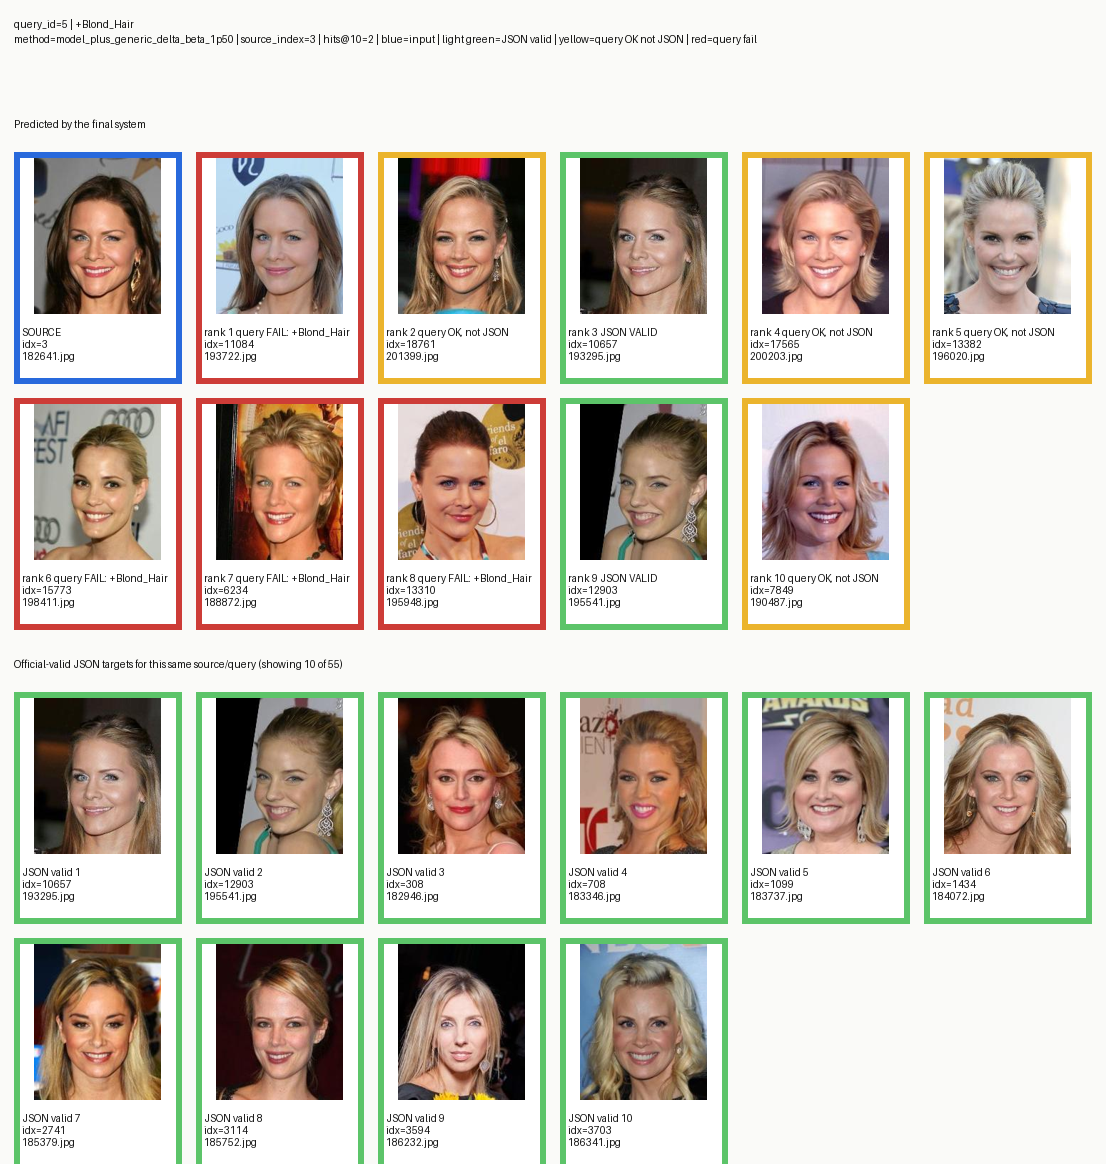

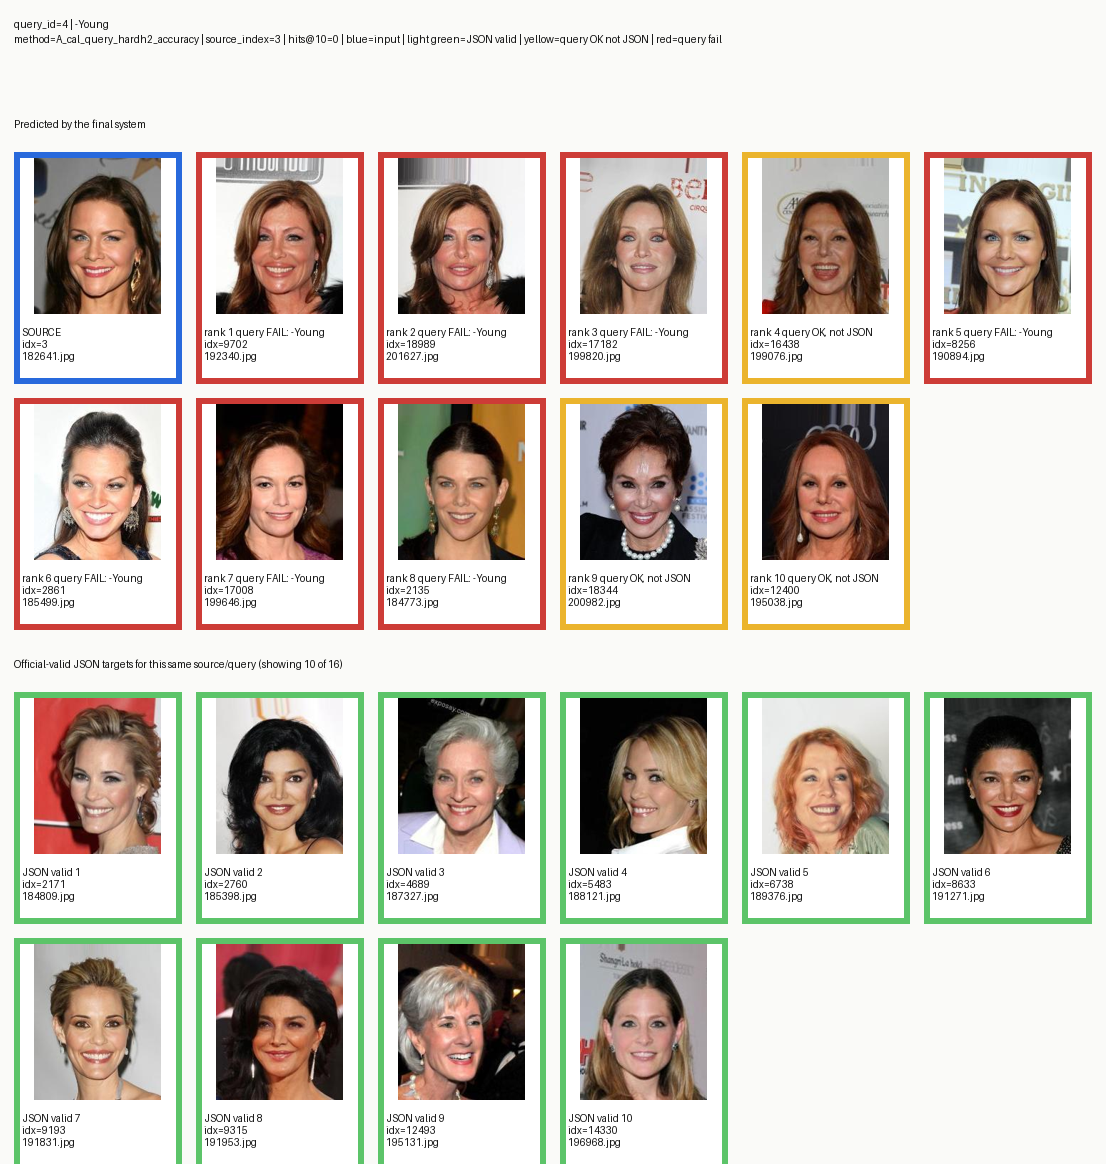


In [ ]:
# List valid source indices for each official JSON query.
# This avoids errors such as source_index=3 not found for query_id=10.
import json
from pathlib import Path

evaluation_path = Path("celeba_evaluation.json")
if not evaluation_path.exists():
    evaluation_path = Path("cluster/data/celeba_evaluation.json")

evaluation = json.loads(evaluation_path.read_text())
for query_id, entry in enumerate(evaluation):
    sources = sorted(map(int, entry["ground_truth"].keys()))
    preview = ", ".join(map(str, sources[:12]))
    print(f"query_id={query_id:02d} | {entry['query']:<45} | sources={len(sources):5d} | examples: {preview}")


## Open-vocabulary and multi-attribute qualitative tests

The official evaluation only covers the 40 CelebA attributes, but our final system operates in CLIP embedding space. This means we can also run qualitative open-vocabulary tests with concepts that were never part of the supervised CelebA label set. These examples are **not** official metrics, because no ground-truth labels exist for them; they are visual sanity checks for semantic compositionality.

For an open attribute such as `Sunglasses` or `visible teeth`, the edit direction is computed from CLIP text embeddings:

```text
d = normalize(CLIP_text("a portrait photo of a face with <attribute>")
              - CLIP_text("a portrait photo of a face without <attribute>"))
```

The same learned sequential gate and vector-delta correction then operate on these directions together with known CelebA directions. Yellow borders mean that the known CelebA part of the query is satisfied, while the open-vocabulary part is visually inspected but not label-verifiable.

### Single-attribute sanity check: eyeglasses vs sunglasses

We keep one simple single-attribute example to introduce the idea. With the same source image, `+Eyeglasses` retrieves regular/prescription glasses, while `+Sunglasses` retrieves darker/tinted sunglasses. This suggests that the CLIP-space edit direction distinguishes related but different concepts.

<table>
<tr>
<td><strong>Known CelebA: +Eyeglasses</strong></td>
<td><strong>Open CLIP: +Sunglasses</strong></td>
</tr>
<tr>
<td>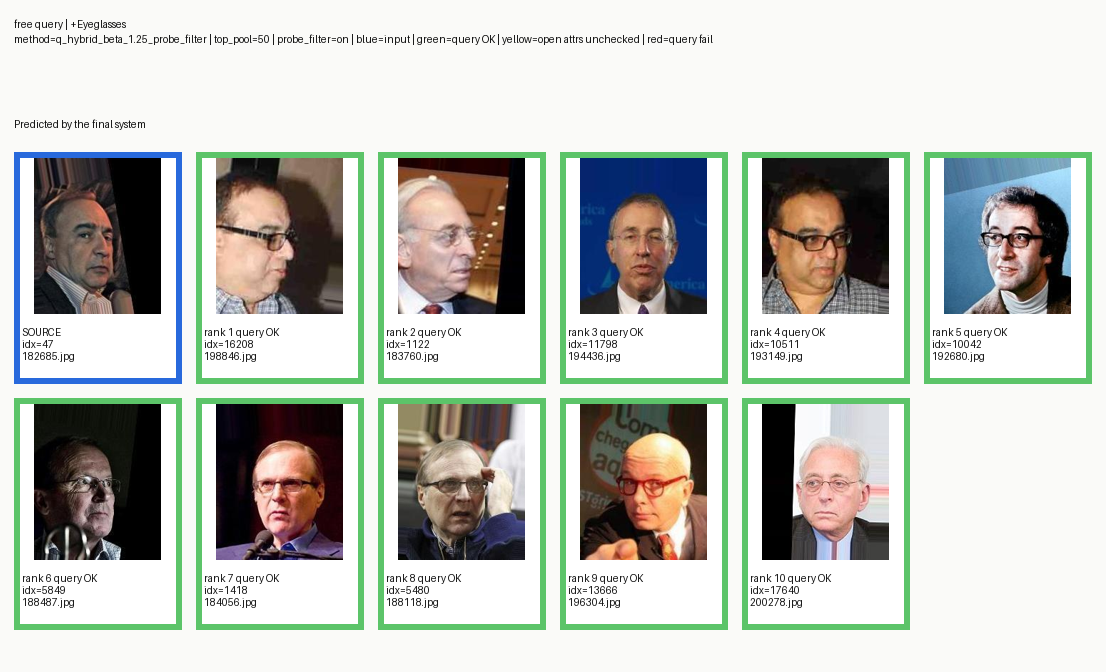</td>
<td>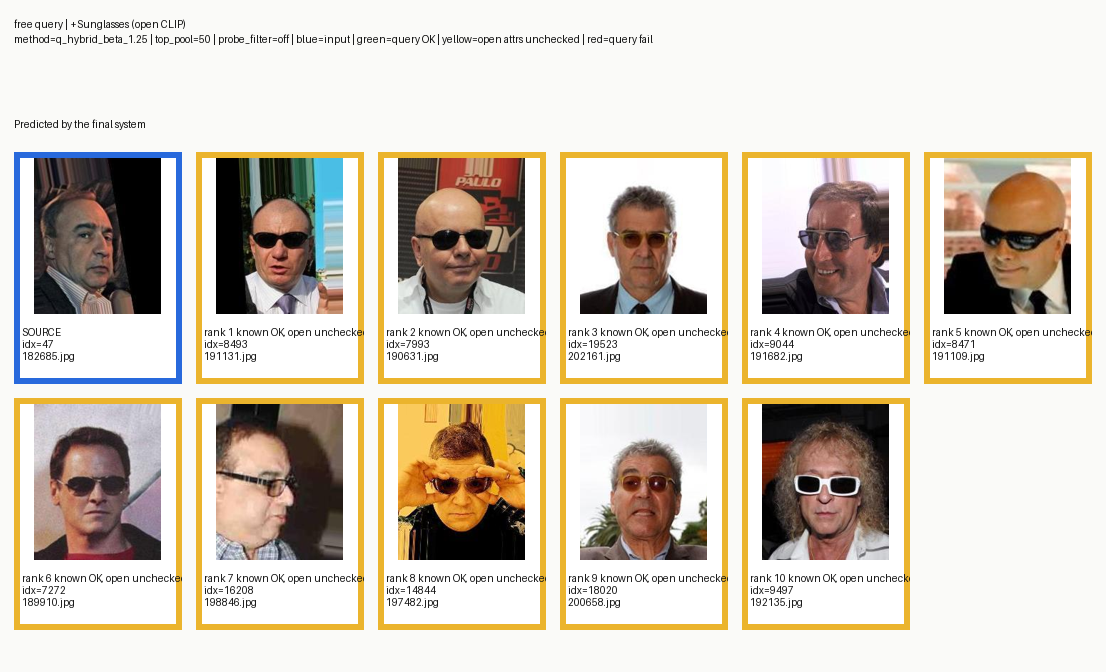</td>
</tr>
</table>

### Multi-attribute open-vocabulary examples

The more interesting case is when multiple edits are requested at once, mixing known CelebA attributes with unknown open-vocabulary ones. Below we use the same source identity and vary combinations such as `visible teeth`, `Eyeglasses`, `Sunglasses`, and `white skin`. The examples show that the system can often move toward the requested combination while preserving a coherent face neighborhood.

<table>
<tr>
<td><strong>-visible teeth, -Eyeglasses</strong></td>
<td><strong>+white skin, -visible teeth, -Eyeglasses</strong></td>
</tr>
<tr>
<td>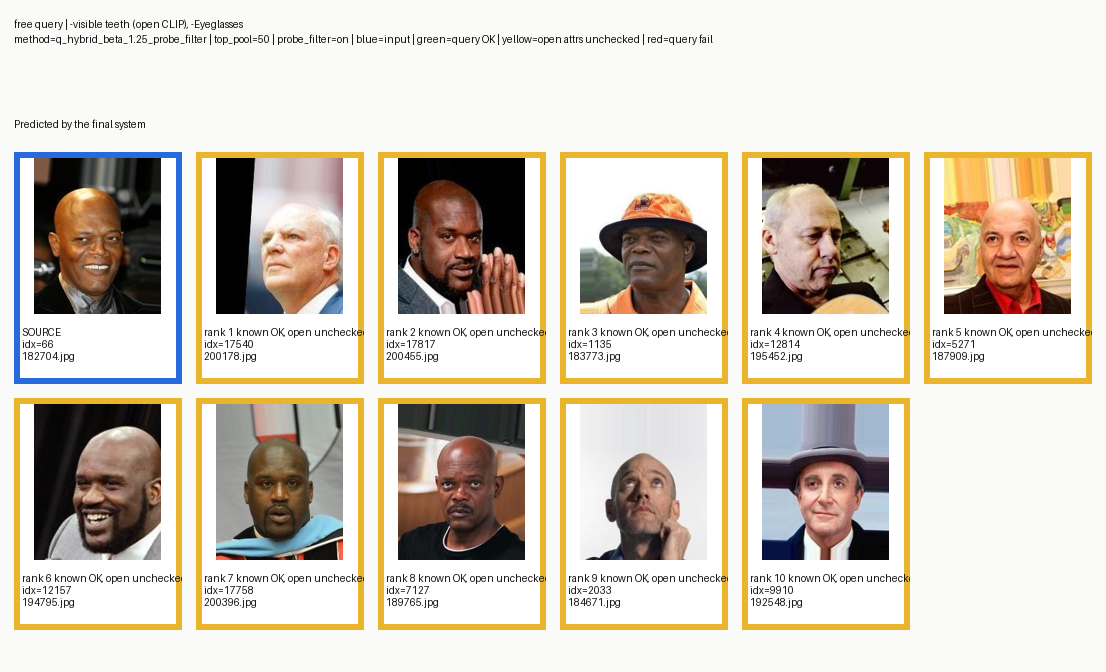</td>
<td>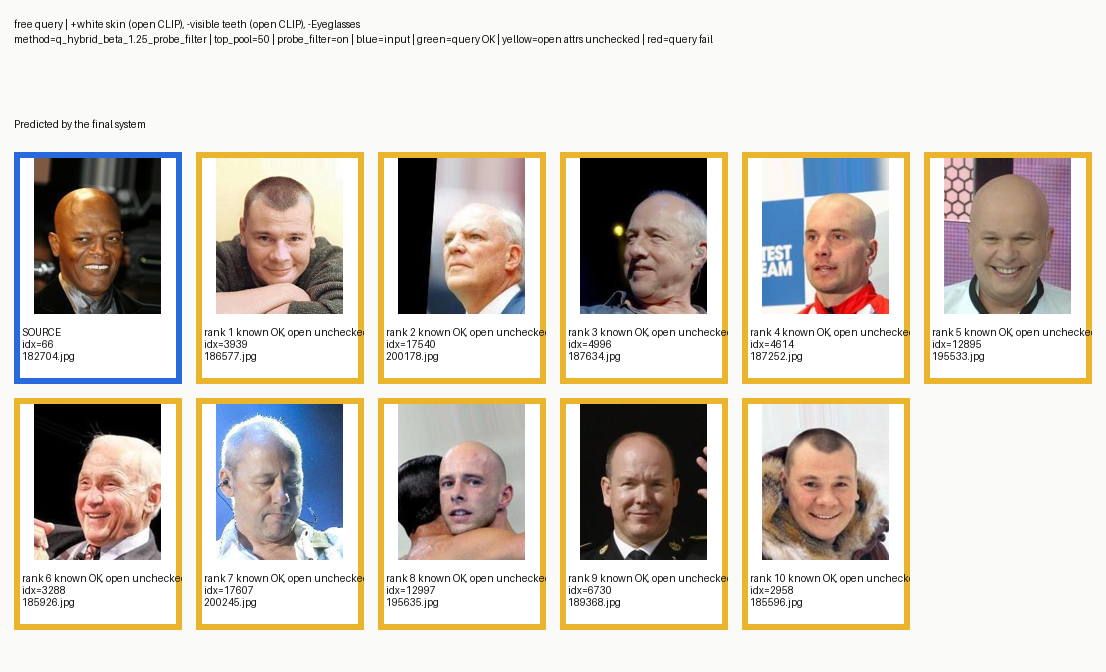</td>
</tr>
</table>

<table>
<tr>
<td><strong>-visible teeth, +Eyeglasses</strong></td>
</tr>
<tr>
<td>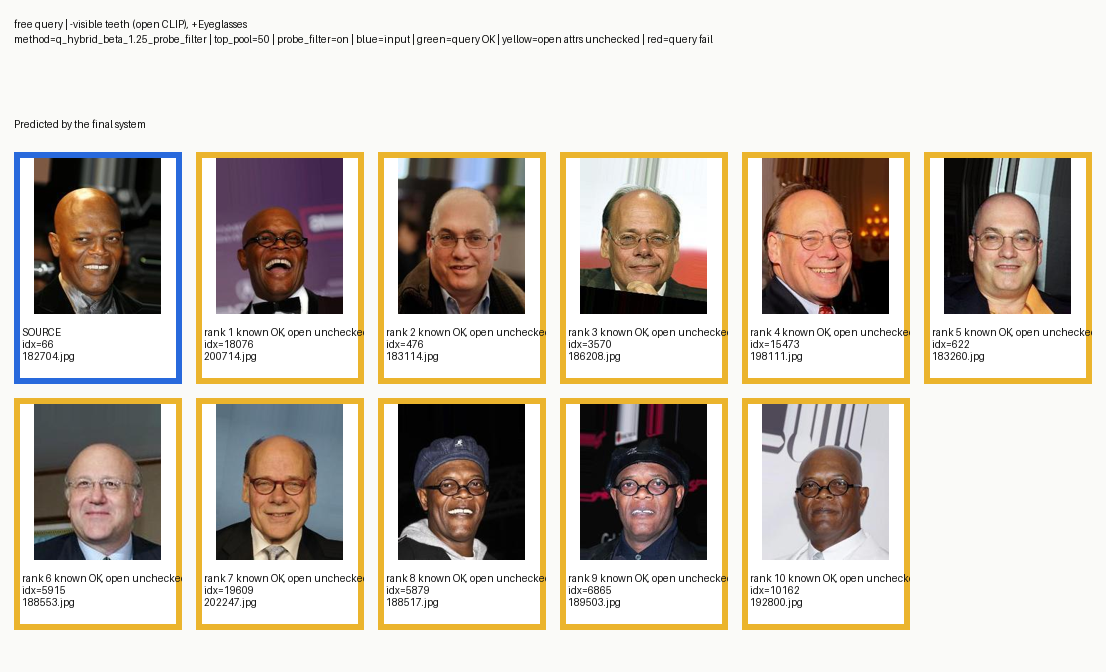</td>
</tr>
</table>


<table>
<tr>
<td><strong>+visible teeth, +sunglasses</strong></td>
</tr>
<tr>
<td>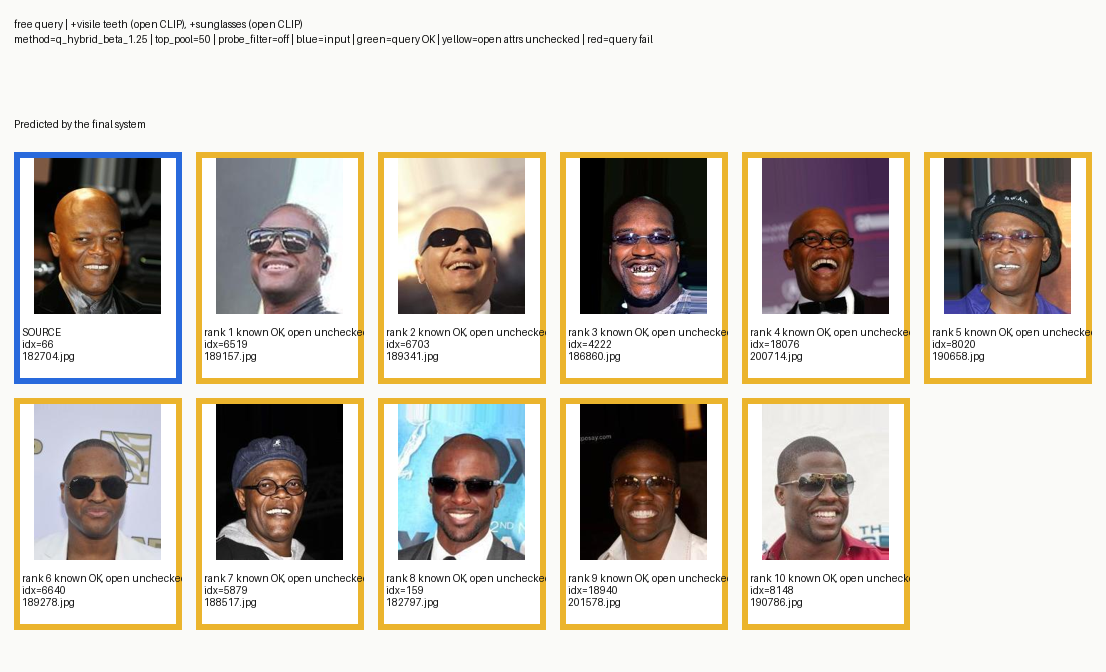</td>
</tr>
</table>

These examples are useful for discussion because they demonstrate two things: first, the system can compose more than one requested edit; second, some requested edits can be concepts not present in the training labels but still present in CLIP semantic space.
